<a href="https://colab.research.google.com/github/AbubakkarAslam/Deep-Learning-Journey/blob/main/05_image_classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import PIL
import shutil
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.models import Sequential
import os

# Print some roses of different categories
rose = list(pathlib.Path(dataset_dir).glob("roses/*"))
for i in range(3):
  PIL.Image.open(str(rose[i]))

In [7]:
# lets load the dataset of images from tensorflow
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
dataset = tf.keras.utils.get_file("flower_photos.tgz", origin=dataset_url, extract=True, untar=True, cache_dir='.', cache_subdir='')
# data_dir = pathlib.Path(data_dir).parent / "flower_photos_extracted" / "flower_photos"
dataset_dir = os.path.join(os.path.dirname(dataset), 'flower_photos_extracted/flower_photos')

In [8]:
# Lets see how many directories insie the dataset
print(os.listdir(dataset_dir))

['LICENSE.txt', 'sunflowers', 'tulips', 'daisy', 'roses', 'dandelion']


In [14]:
import pathlib
# Check how many data of flower in the dataset
image_count = len(list(pathlib.Path(dataset_dir).glob("*/*.jpg")))
print(image_count)

3670


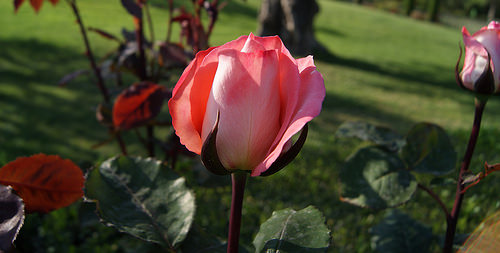

In [31]:
# Print some roses flower
rose = list(pathlib.Path(dataset_dir).glob("roses/*"))
# for i in range(3):
#  display(PIL.Image.open(str(rose[i])))


# secound: if one image want to show
PIL.Image.open(str(rose[1]))

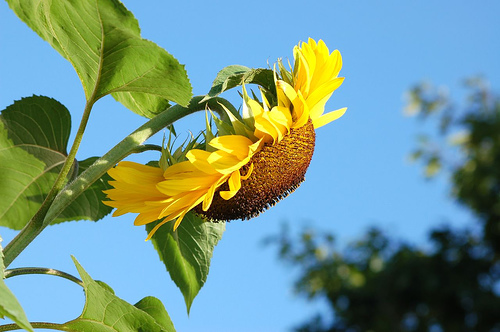

In [32]:
# Print some sunflowers flower
sunflowers = list(pathlib.Path(dataset_dir).glob("sunflowers/*"))
# for i in range(3):
#   display(PIL.Image.open(str(sunflowers[i])))

PIL.Image.open(str(sunflowers[1]))

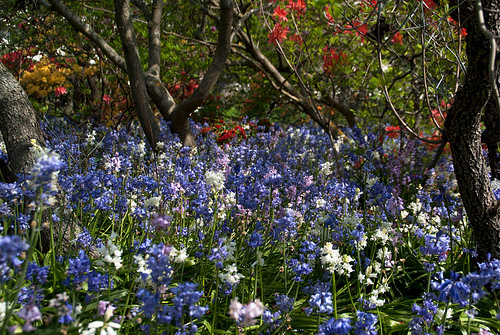

In [36]:
tulips = list(pathlib.Path(dataset_dir).glob('tulips/*'))

# for i in range(3):
#   display(PIL.Image.open(str(tulips[i])))



PIL.Image.open(str(tulips[1]))

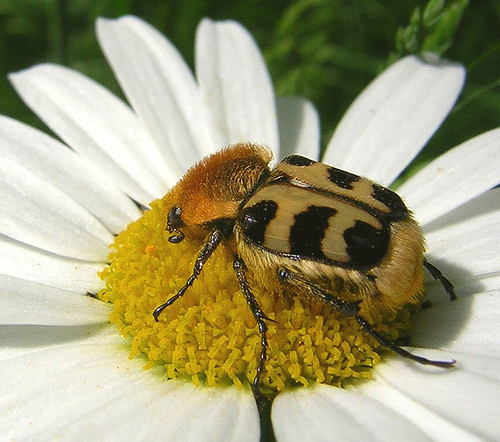

In [37]:
# Display the daisy image
daisy = list(pathlib.Path(dataset_dir).glob('daisy/*'))
# for i in range(3):
#   display(PIL.Image.open(str(daisy[i])))


PIL.Image.open(str(daisy[1]))

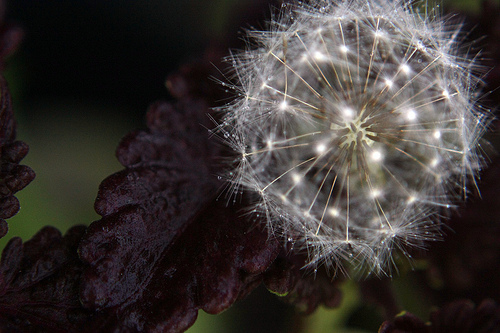

In [38]:
# Display the dandelion images
dandelion = list(pathlib.Path(dataset_dir).glob('dandelion/*'))

# for i in range(3):
#   display(PIL.Image.open(str(dandelion[i])))



PIL.Image.open(str(dandelion[1]))

In [47]:
import os

# Get class names from the subdirectories in dataset_dir
class_names = keras.utils.image_dataset_from_directory(dataset_dir)
print(class_names)

Found 3670 files belonging to 5 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Load the dataset by using the keras utils

In [48]:
# first declair the batch_size, image_height, image_width

batch_size = 32
img_height = 180
img_width = 180

In [49]:
# split the data into train and validation by validatio_split
# This is for training the data
train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='training',
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [51]:
# This is for validation
val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='validation',
    seed = 123,
    batch_size=batch_size,
    image_size=(img_height, img_width)
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


You can find the class names in the `class_names` attribute on these datasets. These correspond to the directory names in alphabetical order.

In [55]:
train_class_names = train_ds.class_names
print(train_class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Visualize the data

Here are the first nine images from the training dataset:

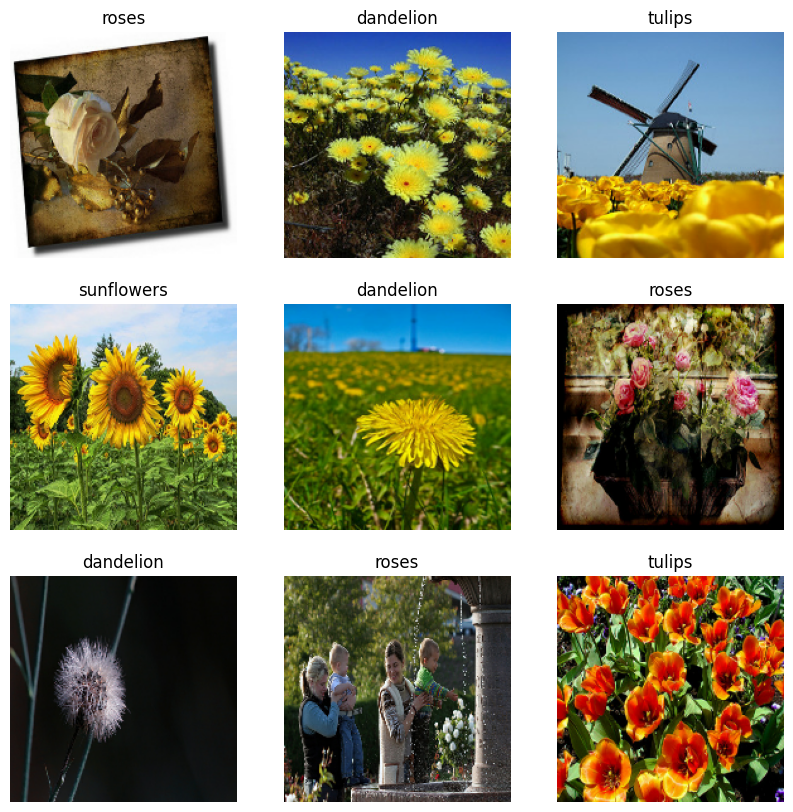

In [56]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [58]:
# Now check the shape of the training data
for batch, label in train_ds:
  print(label.shape)
  print(batch.shape)
  break

(32, 180, 180, 3)
(32,)


- `Dataset.cache` keeps the images in memory after they're loaded off disk during the first epoch. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache.
- `Dataset.prefetch` overlaps data preprocessing and model execution while training.

In [63]:
# Autotune  the data and load in cache
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


## Standardize the data


The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small.

Here, you will standardize values to be in the `[0, 1]` range by using `tf.keras.layers.Rescaling`:

In [64]:
normalizer = layers.Rescaling(1./255)